In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
country = 'United States'

df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country']==country)].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [3]:
df_DA_US = df_DA_US.explode('job_skills')

In [4]:
df_skill_grouped = df_DA_US.groupby(by='job_skills')['salary_year_avg'].agg(['count', 'median'])

In [7]:
df_skill_high_pay = df_skill_grouped.sort_values(by='median', ascending=False).head(10)
df_skill_high_demand = df_skill_grouped.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

df_skill_high_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


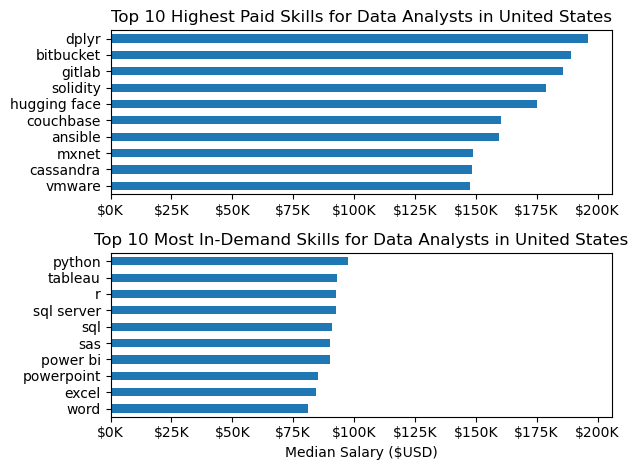

In [ ]:
fig, ax = plt.subplots(2,1)

df_skill_high_pay[::-1].plot(kind='barh', y='median' ,ax=ax[0], legend=False)
ax[0].set_title(f'Top 10 Highest Paid Skills for Data Analysts in {country}')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))

df_skill_high_demand[::-1].plot(kind='barh', y='median' ,ax=ax[1], legend=False)
ax[1].set_title(f'Top 10 Most In-Demand Skills for Data Analysts in {country}')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))

fig.tight_layout()

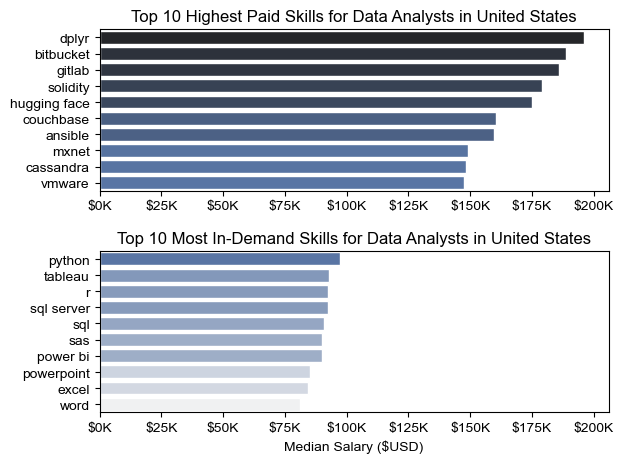

In [28]:
import seaborn as sns

fig, ax = plt.subplots(2,1)

sns.set_theme(style='ticks')
sns.barplot(df_skill_high_pay, x='median', y=df_skill_high_pay.index, ax=ax[0], hue='median', palette='dark:b_r')
# df_skill_high_pay[::-1].plot(kind='barh', y='median' ,ax=ax[0], legend=False)
ax[0].set_title(f'Top 10 Highest Paid Skills for Data Analysts in {country}')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
ax[0].legend().remove()

sns.barplot(df_skill_high_demand, x='median', y=df_skill_high_demand.index, ax=ax[1], hue='median', palette='light:b')
# df_skill_high_demand[::-1].plot(kind='barh', y='median' ,ax=ax[1], legend=False)
ax[1].set_title(f'Top 10 Most In-Demand Skills for Data Analysts in {country}')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
ax[1].legend().set_visible(False)

fig.tight_layout()